# Data Scope Test — Tournament-Only vs. Tournament + Regular Season

**Question this notebook answers:** should the model keep training only on historical tournament
games (current approach, ~4,300 games total), or would it be safe to widen training to include
regular-season games too (hundreds of thousands more games)? This is the training-data-scope
question raised at the July 16 meeting.

**Method:** compare the statistical distribution of game winning-margins (score of the winner
minus score of the loser) between regular-season games and tournament games, separately for
men's and women's basketball. If the two distributions look statistically similar, that supports
widening — the extra regular-season games would look like "more of the same" to the model. If
they look meaningfully different, that argues for keeping training scoped to tournament games
only, since mixing in a different kind of game could teach the model the wrong lessons.

Three complementary tests are used, each checking a different aspect of "similar distribution":
Levene's test (spread), Welch's t-test (average), and the Kolmogorov-Smirnov test (overall shape).
All three are hand-written below (scipy isn't available in this sandbox) and verified against
synthetic data with a known right answer before being trusted on the real data — same approach
used for the hand-written logistic regression in notebook 03.

## 1. Load data

Regular-season and tournament compact results for both men's and women's basketball — the same
two files per gender used throughout this project.

In [1]:
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.dpi"] = 110

DATA_DIR = Path("../data")

m_reg = pd.read_csv(DATA_DIR / "MRegularSeasonCompactResults.csv")
w_reg = pd.read_csv(DATA_DIR / "WRegularSeasonCompactResults.csv")
m_tourney = pd.read_csv(DATA_DIR / "MNCAATourneyCompactResults.csv")
w_tourney = pd.read_csv(DATA_DIR / "WNCAATourneyCompactResults.csv")

print(f"men's regular season games:   {len(m_reg):,}")
print(f"men's tournament games:       {len(m_tourney):,}")
print(f"women's regular season games: {len(w_reg):,}")
print(f"women's tournament games:     {len(w_tourney):,}")


men's regular season games:   198,577
men's tournament games:       2,585
women's regular season games: 142,507
women's tournament games:     1,717


## 2. The variable being compared: winning margin

For every game, winning margin = winner's score minus loser's score — a simple, direct measure of
how competitive or lopsided a game was. This is the variable being compared because it's exactly
what the `AvgMarginDiff` feature (used in every model so far) is built from — if regular-season
and tournament margins come from different distributions, folding regular-season games into
training would be teaching the model a different notion of "typical margin" than what it will
actually see at tournament time.

In [2]:
def margins(df):
    return (df["WScore"] - df["LScore"]).values

m_reg_margin, m_tny_margin = margins(m_reg), margins(m_tourney)
w_reg_margin, w_tny_margin = margins(w_reg), margins(w_tourney)

summary = pd.DataFrame([
    {"Group": "Men's regular season", "N": len(m_reg_margin), "Mean": m_reg_margin.mean(), "Std": m_reg_margin.std(ddof=1)},
    {"Group": "Men's tournament", "N": len(m_tny_margin), "Mean": m_tny_margin.mean(), "Std": m_tny_margin.std(ddof=1)},
    {"Group": "Women's regular season", "N": len(w_reg_margin), "Mean": w_reg_margin.mean(), "Std": w_reg_margin.std(ddof=1)},
    {"Group": "Women's tournament", "N": len(w_tny_margin), "Mean": w_tny_margin.mean(), "Std": w_tny_margin.std(ddof=1)},
])
print(summary.round(2).to_string(index=False))


                 Group      N  Mean   Std
  Men's regular season 198577 12.09  9.41
      Men's tournament   2585 11.82  8.90
Women's regular season 142507 14.44 11.06
    Women's tournament   1717 16.73 12.65


## 3. Test 1 — Levene's test (do the two groups have similarly-sized spreads?)

This checks whether one group's margins are more variable than the other's — e.g. regular season
having a wide mix of blowouts and close games, vs. tournament games clustering tighter around a
typical margin (or vice versa). The classic version of this check is the F-test, but it assumes
the underlying data is bell-shaped (normally distributed) — margins aren't; they're bounded at 0
and skewed toward blowouts. Levene's test does the same job without that assumption: instead of
comparing the raw numbers directly, it compares how far each game's margin sits from its own
group's *median*, which is far less sensitive to skew.

**How it's calculated:** for each group, take the absolute distance of every game's margin from
that group's median margin. Then run a standard equal-means test (an F-test) on those distances
instead of on the raw margins. If the distances themselves differ systematically between groups,
that means one group is more spread out than the other.

In [3]:
def norm_cdf(x):
    return 0.5 * (1 + math.erf(x / np.sqrt(2)))

def levene_test(a, b):
    """Levene's test (Brown-Forsythe, median-centered) for equality of variance between two
    groups. Returns the W statistic and a p-value. W ~ F(1, N-2) under the null hypothesis; with
    N in the thousands here, F(1, N-2) is essentially indistinguishable from a chi-square(1)
    distribution, which is just a squared standard normal - that's the approximation used below
    instead of implementing the full F-distribution."""
    z_a = np.abs(a - np.median(a))
    z_b = np.abs(b - np.median(b))
    n_a, n_b = len(a), len(b)
    N = n_a + n_b
    zbar_a, zbar_b = z_a.mean(), z_b.mean()
    zbar = np.concatenate([z_a, z_b]).mean()
    between = n_a * (zbar_a - zbar) ** 2 + n_b * (zbar_b - zbar) ** 2
    within = np.sum((z_a - zbar_a) ** 2) + np.sum((z_b - zbar_b) ** 2)
    W = (N - 2) * between / within
    p = 2 * (1 - norm_cdf(np.sqrt(W)))
    return W, p

print("Levene's test function ready")


Levene's test function ready


**Sanity check before trusting this on real data:** run it on synthetic data where the right
answer is already known — two same-shaped groups (should NOT flag a difference) and two
groups built with genuinely different spread (SHOULD flag a difference).

In [4]:
rng = np.random.default_rng(0)
same_spread_a = rng.normal(0, 1, 5000)
same_spread_b = rng.normal(0, 1, 5000)
diff_spread_a = rng.normal(0, 1, 5000)
diff_spread_b = rng.normal(0, 2, 5000)   # 2x the standard deviation

W1, p1 = levene_test(same_spread_a, same_spread_b)
W2, p2 = levene_test(diff_spread_a, diff_spread_b)
print(f"same spread   (should NOT be significant): W={W1:.2f}, p={p1:.4f}")
print(f"2x spread     (SHOULD be significant):      W={W2:.2f}, p={p2:.6f}")


same spread   (should NOT be significant): W=0.02, p=0.8983
2x spread     (SHOULD be significant):      W=1675.35, p=0.000000


### Levene's test on the real data

In [5]:
lev_men_W, lev_men_p = levene_test(m_reg_margin, m_tny_margin)
lev_women_W, lev_women_p = levene_test(w_reg_margin, w_tny_margin)
print(f"Men's:   regular season std={m_reg_margin.std(ddof=1):.2f} vs tournament std={m_tny_margin.std(ddof=1):.2f}  ->  W={lev_men_W:.2f}, p={lev_men_p:.6f}")
print(f"Women's: regular season std={w_reg_margin.std(ddof=1):.2f} vs tournament std={w_tny_margin.std(ddof=1):.2f}  ->  W={lev_women_W:.2f}, p={lev_women_p:.6f}")


Men's:   regular season std=9.41 vs tournament std=8.90  ->  W=2.42, p=0.119515
Women's: regular season std=11.06 vs tournament std=12.65  ->  W=43.34, p=0.000000


## 4. Test 2 — Welch's t-test (do the two groups have a different average margin?)

This checks whether the *typical* margin is different between regular season and tournament
games, not just how spread out they are. Welch's version (rather than the basic version) does not
assume the two groups have equal variance — using it here is deliberate, since Test 1 above is
specifically checking whether that assumption even holds.

**How it's calculated:** take the difference between the two groups' average margins, and divide
by the uncertainty in that difference (based on each group's own spread and sample size). A big
number (positive or negative) means the gap between the averages is large relative to the noise;
a value near 0 means the averages are close enough to be explained by chance. With sample sizes in
the thousands here, this statistic behaves essentially like a standard normal value, which is what
is used below to turn it into a p-value.

In [6]:
def welch_t_test(a, b):
    n_a, n_b = len(a), len(b)
    mean_a, mean_b = a.mean(), b.mean()
    var_a, var_b = a.var(ddof=1), b.var(ddof=1)
    se = np.sqrt(var_a / n_a + var_b / n_b)
    t = (mean_a - mean_b) / se
    p = 2 * (1 - norm_cdf(abs(t)))
    return t, p

# sanity check: same mean (should NOT be significant) vs a real mean shift (SHOULD be significant)
same_mean_a = rng.normal(0, 1, 5000)
same_mean_b = rng.normal(0, 1, 5000)
diff_mean_a = rng.normal(0, 1, 5000)
diff_mean_b = rng.normal(0.5, 1, 5000)
t1, tp1 = welch_t_test(same_mean_a, same_mean_b)
t2, tp2 = welch_t_test(diff_mean_a, diff_mean_b)
print(f"same mean      (should NOT be significant): t={t1:.2f}, p={tp1:.4f}")
print(f"0.5 mean shift (SHOULD be significant):      t={t2:.2f}, p={tp2:.6f}")


same mean      (should NOT be significant): t=0.44, p=0.6619
0.5 mean shift (SHOULD be significant):      t=-23.00, p=0.000000


### Welch's t-test on the real data

In [7]:
t_men, tp_men = welch_t_test(m_reg_margin, m_tny_margin)
t_women, tp_women = welch_t_test(w_reg_margin, w_tny_margin)
print(f"Men's:   regular season mean={m_reg_margin.mean():.2f} vs tournament mean={m_tny_margin.mean():.2f}  ->  t={t_men:.2f}, p={tp_men:.6f}")
print(f"Women's: regular season mean={w_reg_margin.mean():.2f} vs tournament mean={w_tny_margin.mean():.2f}  ->  t={t_women:.2f}, p={tp_women:.6f}")


Men's:   regular season mean=12.09 vs tournament mean=11.82  ->  t=1.51, p=0.131543
Women's: regular season mean=14.44 vs tournament mean=16.73  ->  t=-7.45, p=0.000000


## 5. Test 3 — Kolmogorov-Smirnov test (do the two groups have the same overall shape?)

The first two tests each check one summary number (spread, then average). It's possible for two
distributions to have a similar average and spread while still looking quite different in shape
(e.g. one has more games clustered near a blowout, the other more evenly spread out). The KS test
compares the entire distributions at once.

**How it's calculated:** build each group's cumulative distribution — for every possible margin
value, what fraction of that group's games ended with a margin at or below it. Then find the
single biggest gap between the two groups' cumulative curves, anywhere along the range of
margins. A large gap means the two distributions diverge somewhere in their shape, not just in
their average or spread.

In [8]:
def ks_2samp(a, b):
    a_sorted, b_sorted = np.sort(a), np.sort(b)
    all_sorted = np.sort(np.concatenate([a_sorted, b_sorted]))
    cdf_a = np.searchsorted(a_sorted, all_sorted, side="right") / len(a_sorted)
    cdf_b = np.searchsorted(b_sorted, all_sorted, side="right") / len(b_sorted)
    D = np.max(np.abs(cdf_a - cdf_b))
    n, m = len(a), len(b)
    n_eff = n * m / (n + m)
    lam = np.sqrt(n_eff) * D
    ks = np.arange(1, 101)
    p = np.clip(2 * np.sum((-1.0) ** (ks - 1) * np.exp(-2 * ks ** 2 * lam ** 2)), 0, 1)
    return D, p

# sanity check: same shape (should NOT be significant) vs shifted shape (SHOULD be significant)
D1, p1 = ks_2samp(same_mean_a, same_mean_b)
D2, p2 = ks_2samp(diff_mean_a, diff_mean_b)
print(f"same shape    (should NOT be significant): D={D1:.4f}, p={p1:.4f}")
print(f"shifted shape (SHOULD be significant):      D={D2:.4f}, p={p2:.6f}")


same shape    (should NOT be significant): D=0.0162, p=0.5280
shifted shape (SHOULD be significant):      D=0.1920, p=0.000000


### Kolmogorov-Smirnov test on the real data

In [9]:
D_men, D_men_p = ks_2samp(m_reg_margin, m_tny_margin)
D_women, D_women_p = ks_2samp(w_reg_margin, w_tny_margin)
print(f"Men's:   D={D_men:.4f}, p={D_men_p:.6f}")
print(f"Women's: D={D_women:.4f}, p={D_women_p:.6f}")


Men's:   D=0.0127, p=0.807140
Women's: D=0.0812, p=0.000000


## 6. Visualizing the shape difference

The cumulative distributions the KS test compares, plotted directly — the vertical gap between
the two lines at any point is what the KS test is measuring, and the widest such gap is the D
statistic reported above.

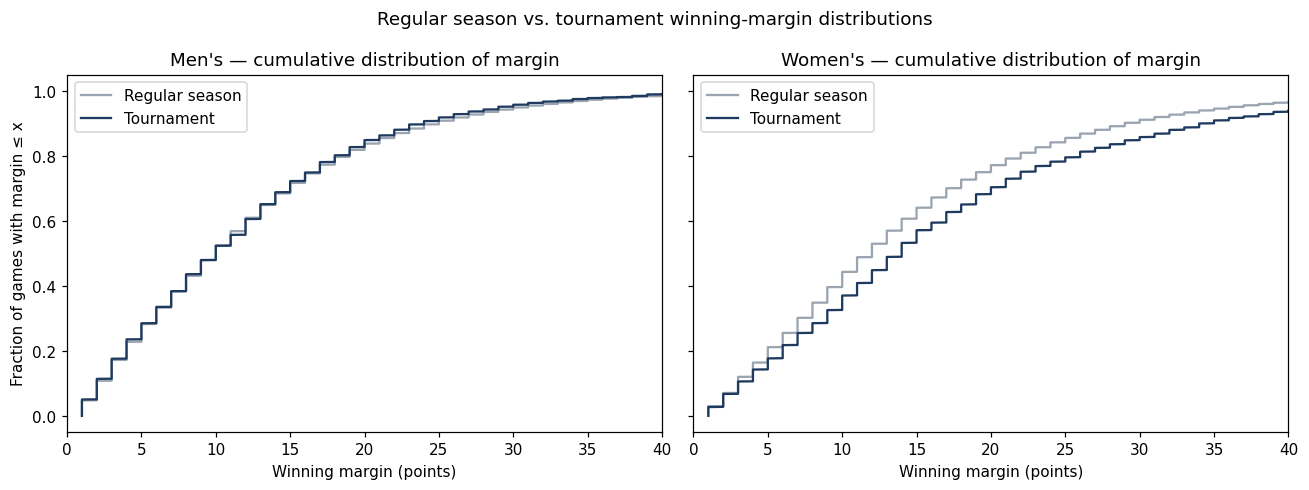

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, reg_m, tny_m, label in [
    (axes[0], m_reg_margin, m_tny_margin, "Men's"),
    (axes[1], w_reg_margin, w_tny_margin, "Women's"),
]:
    reg_sorted, tny_sorted = np.sort(reg_m), np.sort(tny_m)
    ax.plot(reg_sorted, np.arange(1, len(reg_sorted) + 1) / len(reg_sorted), label="Regular season", color="#9aa5b1")
    ax.plot(tny_sorted, np.arange(1, len(tny_sorted) + 1) / len(tny_sorted), label="Tournament", color="#1f3a5f")
    ax.set_xlim(0, 40)
    ax.set_xlabel("Winning margin (points)")
    ax.set_title(f"{label} — cumulative distribution of margin")
    ax.legend()

axes[0].set_ylabel("Fraction of games with margin ≤ x")
fig.suptitle("Regular season vs. tournament winning-margin distributions")
fig.tight_layout()
plt.show()


## 7. All results together

In [11]:
results_df = pd.DataFrame([
    {"Test": "Levene (spread)", "Men's stat": lev_men_W, "Men's p": lev_men_p, "Women's stat": lev_women_W, "Women's p": lev_women_p},
    {"Test": "Welch's t (average)", "Men's stat": t_men, "Men's p": tp_men, "Women's stat": t_women, "Women's p": tp_women},
    {"Test": "KS (overall shape)", "Men's stat": D_men, "Men's p": D_men_p, "Women's stat": D_women, "Women's p": D_women_p},
])
print(results_df.round(6).to_string(index=False))


               Test  Men's stat  Men's p  Women's stat  Women's p
    Levene (spread)    2.423663 0.119515     43.342238        0.0
Welch's t (average)    1.508047 0.131543     -7.446221        0.0
 KS (overall shape)    0.012672 0.807140      0.081237        0.0


## Conclusion

**The decision is different for men's and women's.**

**Men's: safe to widen to tournament + regular season.** All three tests fail to find a real
difference between men's regular-season margins (mean 12.09, std 9.41, n=198,577) and men's
tournament margins (mean 11.82, std 8.90, n=2,585) — Levene's p=0.120, Welch's t-test p=0.132,
KS test p=0.807. None of these clear the usual 0.05 significance threshold, so there's no
statistical evidence that men's regular-season games look like a different kind of game than
men's tournament games. Widening men's training data to include regular-season games is
supported by this test.

**Women's: keep tournament-only.** All three tests find a clear, strong difference between
women's regular-season margins (mean 14.44, std 11.06, n=142,507) and women's tournament margins
(mean 16.73, std 12.65, n=1,717) — Levene's p<0.000001, Welch's t-test p<0.000001, KS test
p<0.000001, with the KS test's biggest single gap between the two cumulative distributions being
8.1 percentage points (D=0.081). Women's tournament games run both bigger in average margin and
more spread out than women's regular-season games. Mixing regular-season games into women's
training would be training on a systematically different distribution of competitiveness than
what the tournament itself looks like, so training stays scoped to tournament-only games for
women's.

This decision is based specifically on the p-values and effect sizes in the Section 7 results
table, cross-checked against the summary statistics in Section 2 and the cumulative-distribution
chart in Section 6.